In [2]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv('../datasets/pcos_dataset.csv')

# Separate features and target
X = df.drop('PCOS_Diagnosis', axis=1)
y = df['PCOS_Diagnosis']

# Store feature names and class labels
feature_names = X.columns.tolist()
class_labels = sorted(y.unique())

print("Feature names:", feature_names)
print("Class labels:", class_labels)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features (important for distance-based algorithms)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize and train Random Forest classifier
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    class_weight='balanced'  # Handles class imbalance
)
rf.fit(X_train, y_train)

# Make predictions
y_pred = rf.predict(X_test)

# Calculate F1 score
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.4f}")

# Feature importance
importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nFeature Importances:")
print(importance)

Feature names: ['Age', 'BMI', 'Menstrual_Irregularity', 'Testosterone_Level(ng/dL)', 'Antral_Follicle_Count']
Class labels: [0, 1]
F1 Score: 0.9870

Feature Importances:
                     Feature  Importance
2     Menstrual_Irregularity    0.383230
1                        BMI    0.336940
3  Testosterone_Level(ng/dL)    0.156048
4      Antral_Follicle_Count    0.120500
0                        Age    0.003283


In [3]:
class_names = ["No PCOS", "Yes PCOS"]

In [4]:
import sys
sys.path.append("../")


Explaining for class: No PCOS


Sampling hypothesis space: 100%|██████████| 500/500 [00:00<00:00, 600.00it/s]


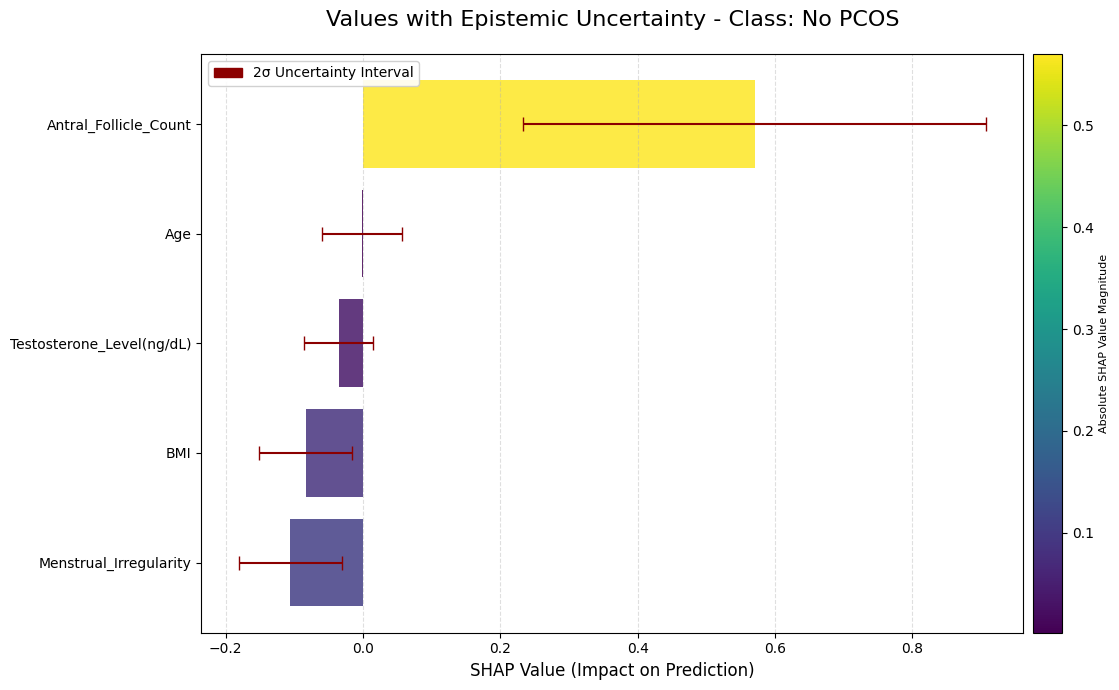

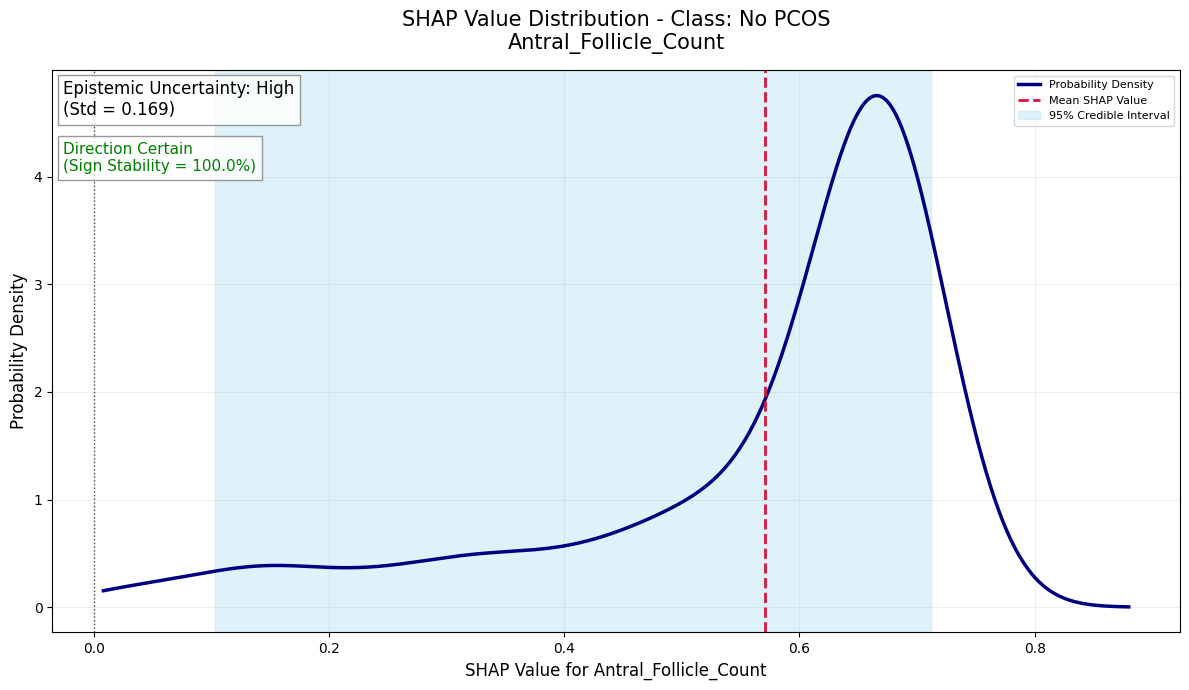

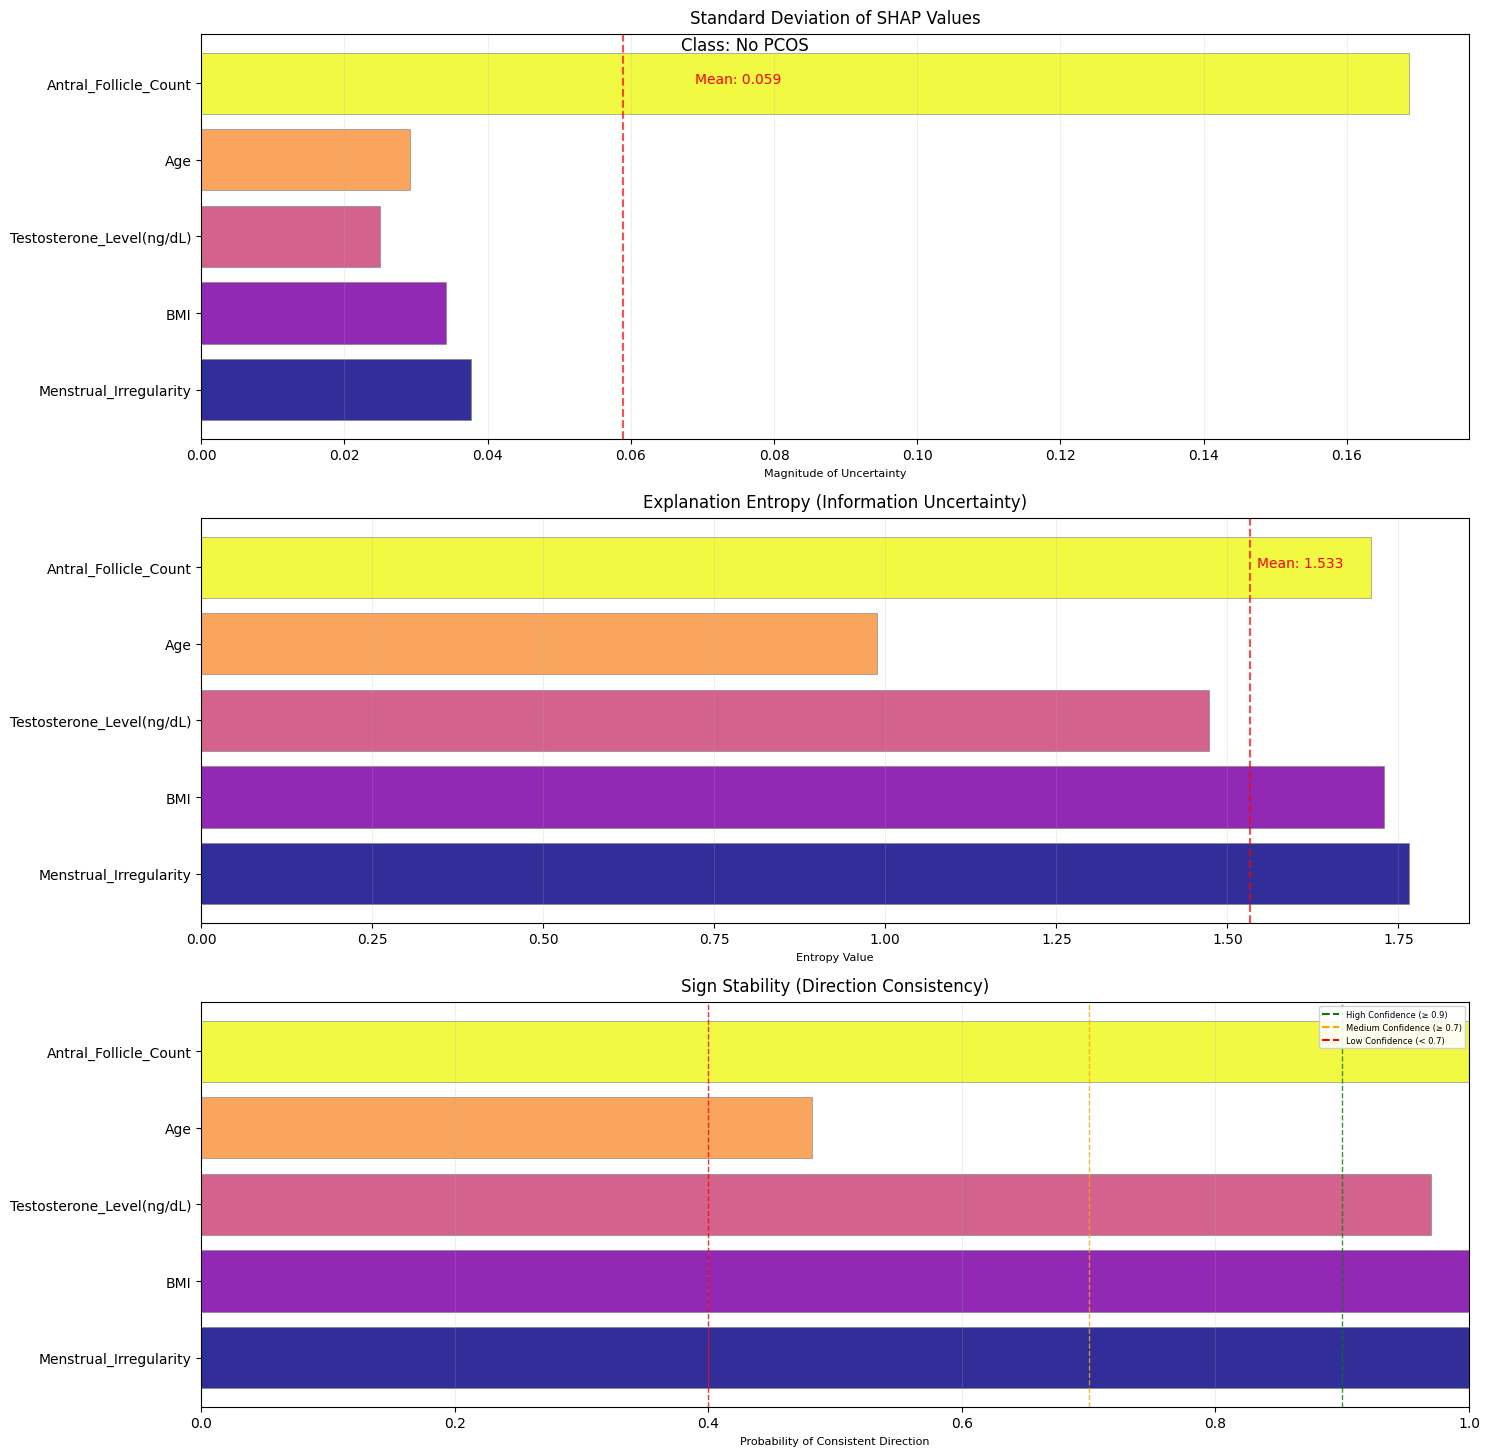


Explaining for class: Yes PCOS


Sampling hypothesis space: 100%|██████████| 500/500 [00:00<00:00, 583.94it/s]


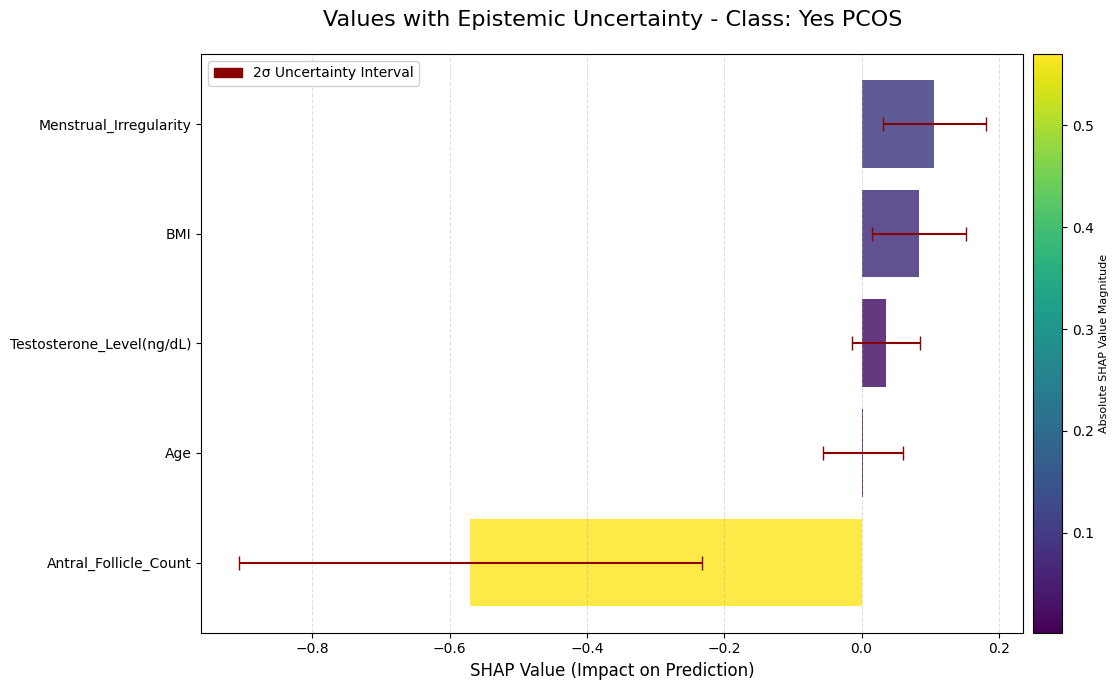

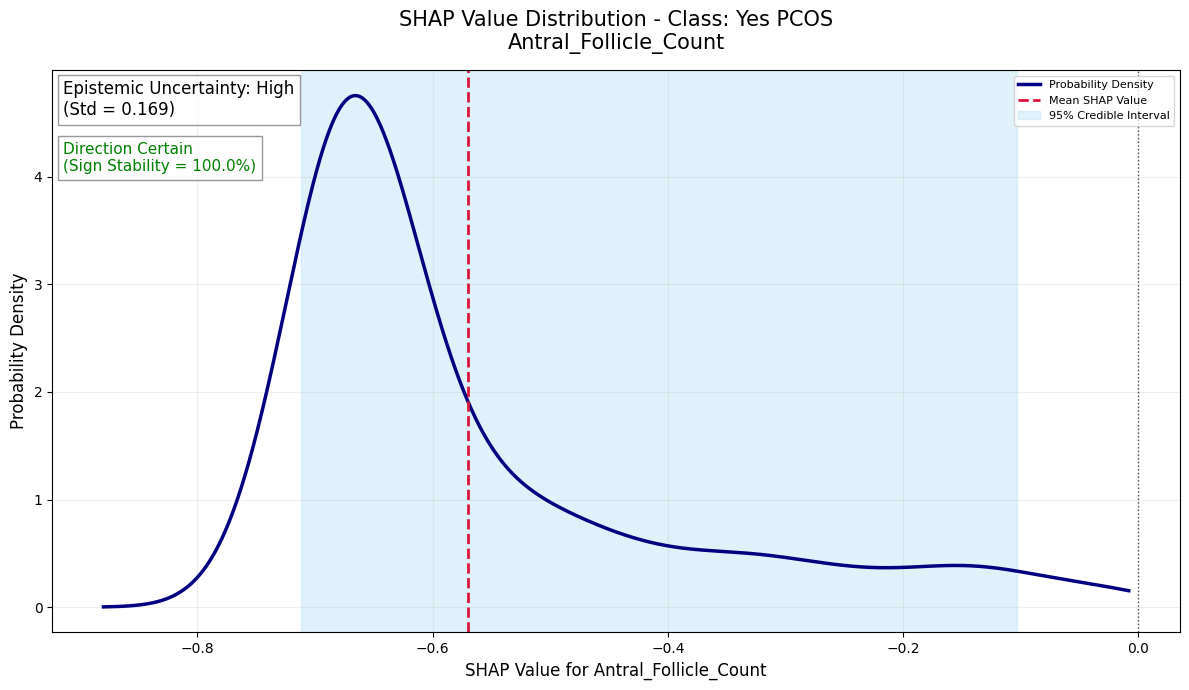

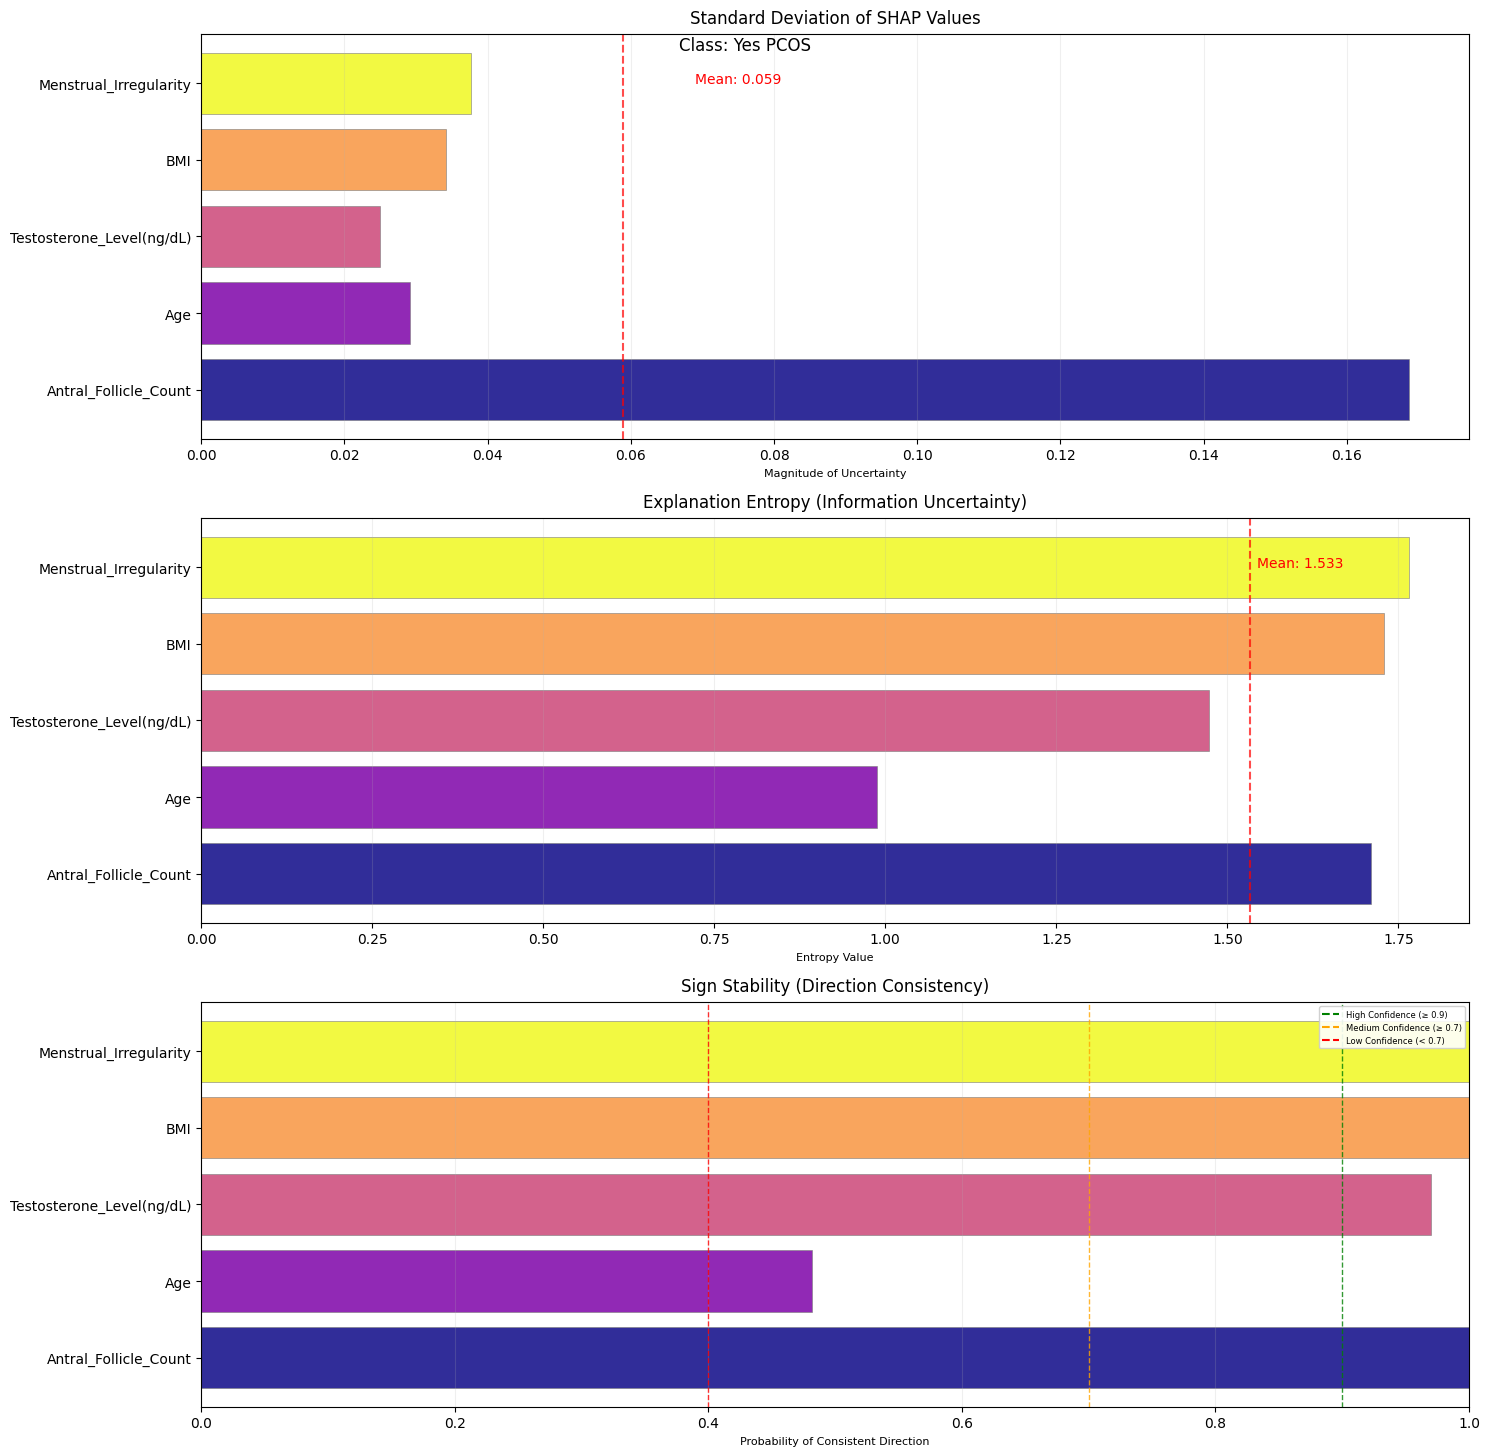

In [15]:
from UQEnTree import ExplainerClassification

import numpy as np
model = rf

explainer = ExplainerClassification(model, X_train, y_train, beta=5.0, random_state=42)

# Explain first instance for each class
instance = X_test[0:1]

for class_idx, class_name in enumerate(class_names):
    print(f"\nExplaining for class: {class_name}")
    results = explainer.explain(instance, class_idx=class_idx)
       # Plot results
    explainer.plot_uncertainty_bars(
        result=results, 
        feature_names= feature_names,
        class_name=class_name
    )
    
    # Plot distribution for most important feature
    most_important_feature = np.argmax(np.abs(results['mean']))
    explainer.plot_uncertainty_distribution(
        results,
        feature_names,
        most_important_feature,
        class_name=class_name
    )
    
    explainer.plot_uncertainty_comparison(
        results,
        feature_names,
        class_name=class_name
    )
